# Seasonal Agriculture Performance Analysis

## Major Project – VOIS AICTE Batch 2026-2027

This project analyzes agricultural performance across Kharif, Rabi and Zaid seasons using data analysis and visualization techniques.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset (1).csv")

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 1. Dataset Overview

The dataset contains agricultural information related to different seasons, crops, farming conditions, resource usage and economic performance.

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [ ]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

## 2. Data Cleaning

In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 120


In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


## 3. Seasonal Analysis

In [ ]:
print(df["Season"].value_counts())

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


### Question 1: How does agricultural yield vary across seasons?

In [ ]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean()

print(season_yield)

Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


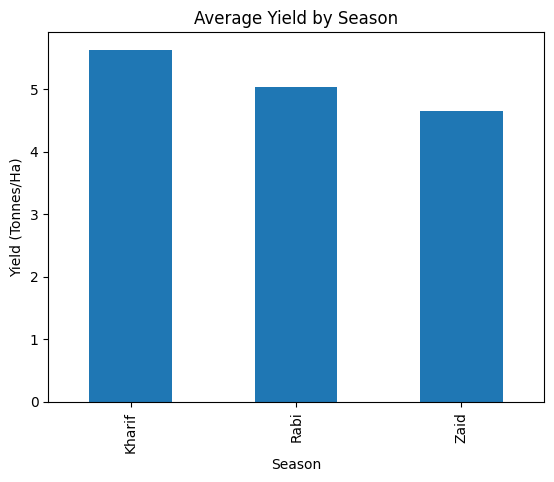

In [ ]:
season_yield.plot(kind="bar")

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

Finding: Kharif has the highest average yield, while Zaid has the lowest average yield in the dataset.

### Question 2: How does average profit vary across seasons?

In [ ]:
season_profit = df.groupby("Season")["Profit_INR"].mean()

print(season_profit)

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


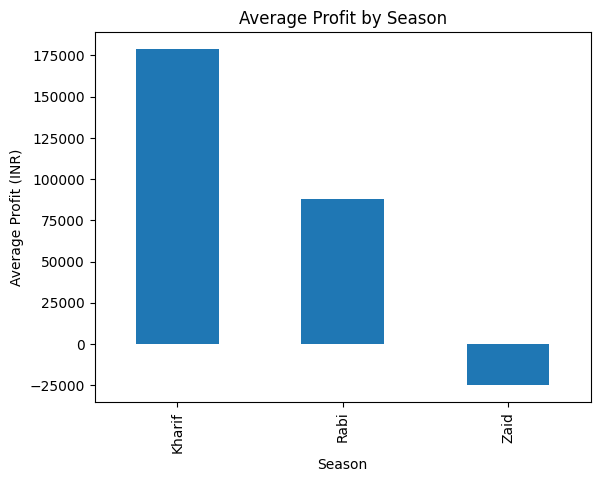

In [ ]:
season_profit.plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.show()

Finding: Kharif shows the highest average profit among the three seasons in the dataset.

### Question 3: Which season has the highest water efficiency?

In [ ]:
water_efficiency = df.groupby("Season")[
    "Water_Efficiency_t_per_1000m3"
].mean()

print(water_efficiency)

Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64


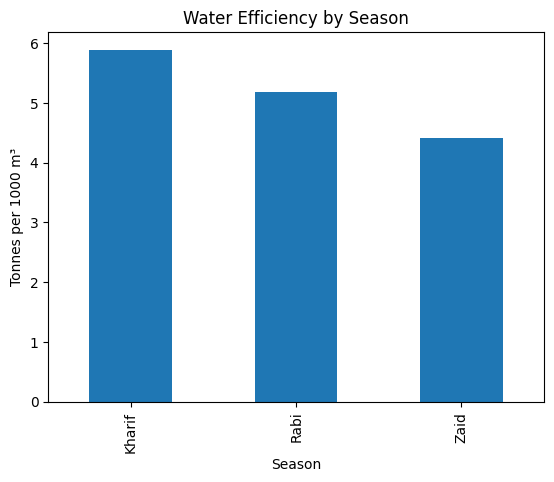

In [ ]:
water_efficiency.plot(kind="bar")

plt.title("Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")

plt.show()

Finding: Kharif has the highest average water efficiency.

### Question 4: How does irrigation method affect agricultural performance?

In [ ]:
irrigation = df.groupby("Irrigation_Method").agg({
    "Yield_Tonnes_Ha": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean"
})

print(irrigation)

                   Yield_Tonnes_Ha     Profit_INR  Water_Used_m3  \
Irrigation_Method                                                  
Drip                      6.577989  219625.997814    5918.747541   
Flood                     4.863977   73354.022901    8026.472519   
Rainfed                   4.602142   79050.365034    3549.554275   
Sprinkler                 5.160627   91121.079019    6208.258856   

                   Water_Efficiency_t_per_1000m3  
Irrigation_Method                                 
Drip                                    6.267129  
Flood                                   3.438853  
Rainfed                                 7.563784  
Sprinkler                               4.669805  


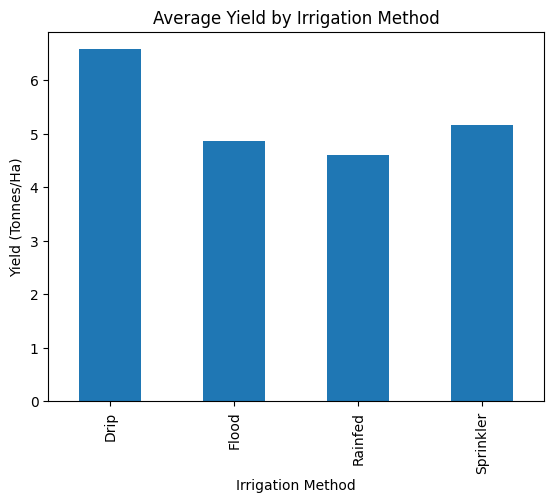

In [ ]:
irrigation["Yield_Tonnes_Ha"].plot(kind="bar")

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

Finding: Drip irrigation has the highest average yield among the irrigation methods in this dataset.

### Question 5: Which crops have the highest average yield?

In [ ]:
crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].mean()

print(crop_yield.sort_values(ascending=False))

Crop
Sugarcane    46.642361
Maize         2.710036
Rice          2.431304
Wheat         2.108013
Chilli        1.542767
Groundnut     1.322901
Cotton        1.229783
Pulses        0.921512
Name: Yield_Tonnes_Ha, dtype: float64


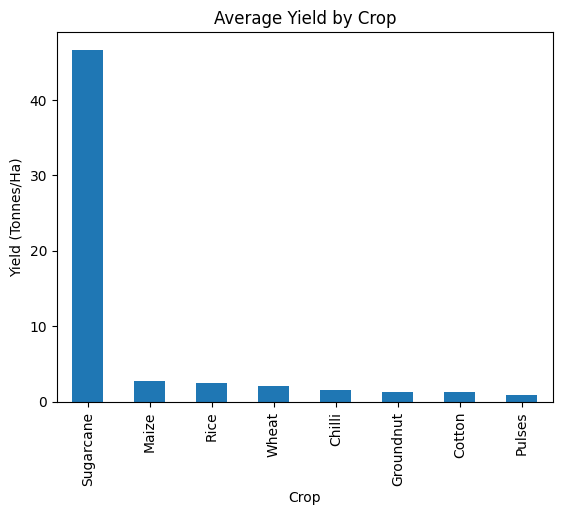

In [ ]:
crop_yield.sort_values(ascending=False).plot(kind="bar")

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

### Question 6: Which crops have the highest average profit?

In [ ]:
crop_profit = df.groupby("Crop")["Profit_INR"].mean()

print(crop_profit.sort_values(ascending=False))

Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Maize        -83978.326679
Rice        -102213.504348
Wheat       -123398.337134
Name: Profit_INR, dtype: float64


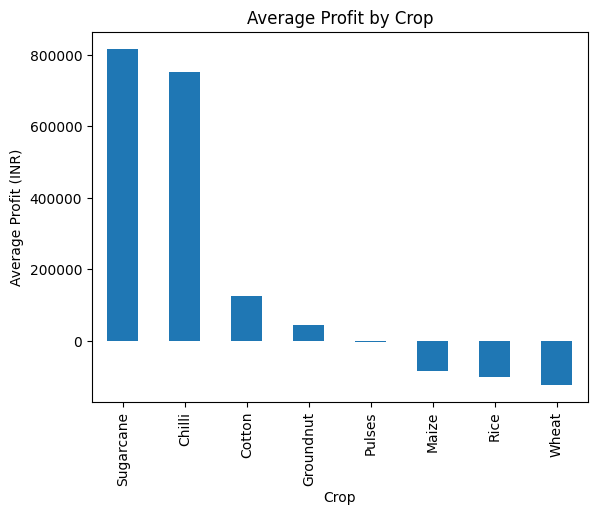

In [ ]:
crop_profit.sort_values(ascending=False).plot(kind="bar")

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")

plt.show()

### Question 7: Is there a relationship between rainfall and yield?

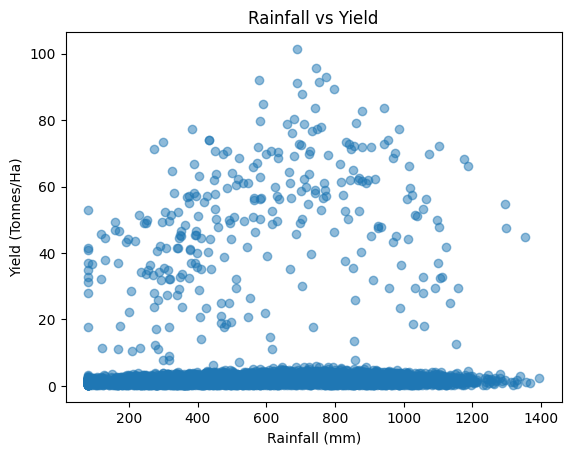

In [ ]:
plt.scatter(
    df["Rainfall_mm"],
    df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

### Question 8: Which factors are strongly related to yield?

In [ ]:
correlation = df.select_dtypes(include=np.number).corr()

print(
    correlation["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912568
Production_Tonnes                0.882813
Profit_INR                       0.488466
Revenue_INR                      0.432152
Water_Used_m3                    0.386294
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Rainfall_mm                      0.030951
Total_Cost_INR                   0.030622
Farm_Area_Hectares               0.030203
Disease_Pest_Risk_pct            0.014292
Humidity_pct                     0.012297
Soil_Moisture_pct                0.010999
Avg_Temperature_C                0.009996
Potassium_kg_ha                  0.003382
Fertilizer_kg_ha                 0.000018
Seed_Quality_Score              -0.007209
Pesticide_Litre_ha              -0.007779
Sunlight_Hours_Day              -0.015341
Soil_pH                         -0.020672
Market_Price_INR_Tonne          -0.382607
Name: Yield_Tonnes_Ha, dtype: float64


Finding: Water efficiency shows a strong positive relationship with yield in this dataset. This indicates association, but it does not prove that water efficiency alone causes higher yield.

## 4. Overall Seasonal Comparison

In [ ]:
summary = df.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Production=("Production_Tonnes", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Disease_Risk=("Disease_Pest_Risk_pct", "mean")
)

summary.round(2)

,Average_Yield,Average_Production,Average_Revenue,Average_Cost,Average_Profit,Average_Water_Used,Water_Efficiency,Disease_Risk
Season,,,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,5.04,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


## 5. Conclusion

The Seasonal Agriculture Performance Analysis was conducted using 4,000 agricultural records. The analysis identified differences in agricultural performance across Kharif, Rabi and Zaid seasons. Kharif recorded the highest average yield, profit and water efficiency. Drip irrigation showed higher average yield compared with the other irrigation methods. Sugarcane recorded the highest average crop yield. The analysis also showed a strong positive relationship between water efficiency and yield. These findings can support better crop selection, irrigation planning and seasonal agricultural decision-making.

## 6. Recommendations

1. Use efficient irrigation methods where suitable.
2. Consider seasonal conditions when selecting crops.
3. Monitor and improve water efficiency.
4. Use historical data for seasonal agricultural planning.
5. Monitor rainfall, temperature and soil conditions.
6. Use predictive models in the future for yield and profit forecasting.

Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64


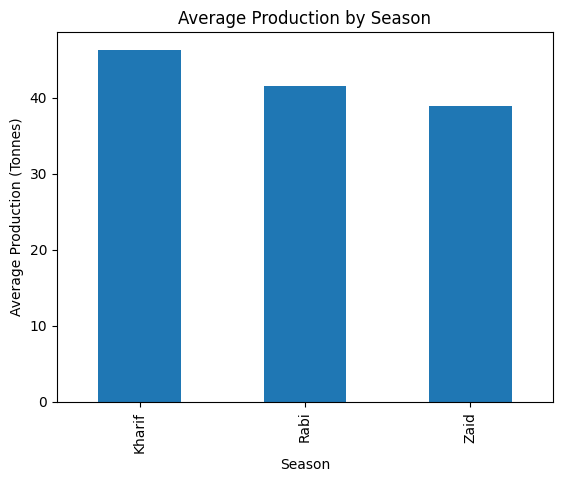

In [ ]:
season_production = df.groupby("Season")["Production_Tonnes"].mean()

print(season_production)

season_production.plot(kind="bar")

plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")
plt.show()

### Finding

The average agricultural production differs across the three seasons.
This indicates that seasonal conditions can influence overall production performance.

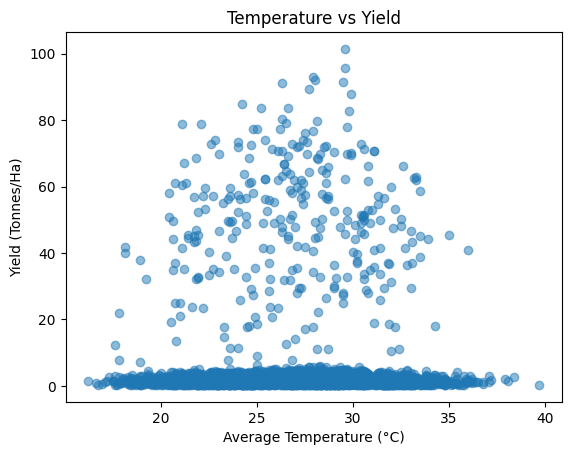

In [ ]:
plt.scatter(
    df["Avg_Temperature_C"],
    df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Temperature vs Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

### Finding

The scatter plot shows the relationship between average temperature and agricultural yield.
The relationship should be interpreted as an association and does not by itself prove causation.

In [ ]:
summary.round(2)


,Average_Yield,Average_Production,Average_Revenue,Average_Cost,Average_Profit,Average_Water_Used,Water_Efficiency,Disease_Risk
Season,,,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,5.04,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


### Seasonal Performance Summary

The summary table compares yield, production, revenue, cost, profit, water usage, water efficiency and disease/pest risk across Kharif, Rabi and Zaid seasons.

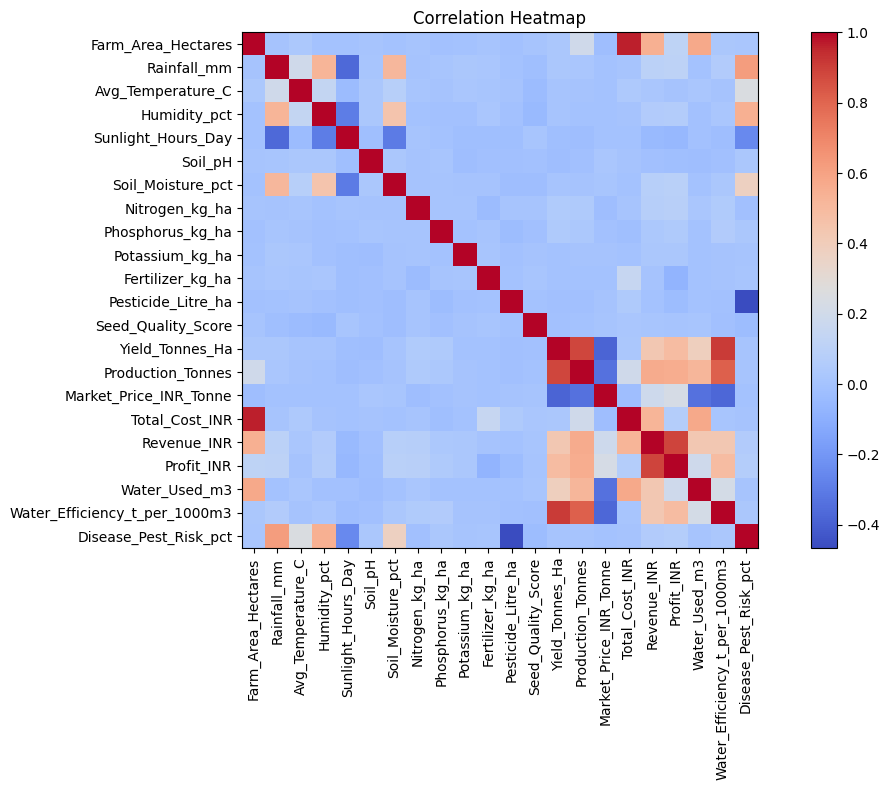

In [ ]:
correlation = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 8))
plt.imshow(correlation, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

## Key Insights

1. Kharif shows the highest average yield among the three seasons.
2. Kharif also records the highest average profit and water efficiency.
3. Drip irrigation shows the highest average yield among the irrigation methods.
4. Sugarcane has the highest average yield among the crops in the dataset.
5. Water efficiency has a strong positive relationship with yield.
6. Agricultural performance varies considerably across seasons.
7. Environmental and resource-related factors should be considered during seasonal agricultural planning.

## Conclusion

The Seasonal Agriculture Performance Analysis was conducted using 4,000 agricultural records. The analysis identified clear differences in agricultural performance across Kharif, Rabi and Zaid seasons.

Kharif recorded the highest average yield, profit and water efficiency. Drip irrigation showed the highest average yield among the irrigation methods, while Sugarcane recorded the highest average crop yield.

The analysis also identified a strong positive relationship between water efficiency and yield. These findings can help support better crop selection, irrigation planning and seasonal agricultural decision-making.